# Clasificador de Emociones en Voz — v2
## Enojo, Tristeza y Feliz · wav2vec2 embeddings · Dataset balanceado 10x10x10

**Resultado:** notebook de comparación final para ejecutar un experimento multiclase consistente.

| Parametro | Valor |
|---|---|
| Modelo de embeddings | `facebook/wav2vec2-base` (768 dims) |
| Dataset | 10 audios por clase seleccionados por score |
| Evaluacion | Leave-One-Out Cross-Validation |
| Clases | Enojo, Tristeza, Feliz |

### Pipeline

1. Filtrado acustico (`scripts/filtrar_audios.py`) descarta audios sin firma emocional
2. Seleccion de los mejores audios por clase segun su score correspondiente
3. Extraccion de embeddings wav2vec2 (mean-pooling temporal)
4. Clasificacion con LOOCV


In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import torch
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              classification_report, balanced_accuracy_score)
warnings.filterwarnings('ignore')
np.random.seed(42)

DATA_DIR  = os.path.join('..', 'data', 'AUDIOS MACHINE LEARNING')
REPORTE   = os.path.join('..', 'outputs', 'reporte_filtrado_v2.csv')
CACHE     = os.path.join('..', 'outputs', 'embeddings_v2.npz')
CLASES    = ['Enojo', 'Tristeza', 'Feliz']
COLORES   = {'Enojo': '#DD8452', 'Tristeza': '#4C72B0', 'Feliz': '#E377C2'}
SCORE_MAP = {'Enojo': 'score_enojo', 'Tristeza': 'score_tristeza', 'Feliz': 'score_feliz'}
TARGET_SR = 16000
DURATION  = 10.0
# Lee N_PER_CLASS desde config.py para mantenerlo sincronizado con el resto del pipeline
import sys
sys.path.insert(0, os.path.abspath('..'))
from config import N_PER_CLASS

DEVICE = 'mps' if torch.backends.mps.is_available() else          'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
print('Clases activas:', CLASES)


Device: mps
Clases activas: ['Enojo', 'Tristeza', 'Feliz']


---
## 1. Seleccion de audios

Usamos el reporte del filtrado acustico para seleccionar los 13 audios
con mayor score emocional por clase.


In [2]:
df_rep = pd.read_csv(REPORTE)

seleccion_por_clase = {}
for clase in CLASES:
    score_col = SCORE_MAP[clase]
    seleccion = (
        df_rep[df_rep['clase_original'] == clase]
        .sort_values(score_col, ascending=False)
        .head(N_PER_CLASS)['archivo']
        .tolist()
    )
    seleccion_por_clase[clase] = seleccion
    print('{} ({}):\n  {}'.format(clase, len(seleccion), seleccion))

print('\nTotal: {} audios balanceados'.format(sum(len(v) for v in seleccion_por_clase.values())))


Enojo (14):
  ['ED_03_ENO_S.ogg', 'ED_04_ENO_S.ogg', 'VZ_02_ENO.ogg', 'MT_05_ENO.ogg', 'MT_03_ENO.ogg', 'MT_10_ENO.ogg', 'MT_02_ENO.ogg', 'VA_03_ENO.ogg', 'MT_06_ENO.ogg', 'VA_11_ENO.ogg', 'MT_07_ENO.ogg', 'ED_02_ENO_S.ogg', 'VA_10_ENO.ogg', 'VA_08_ENO.ogg']
Tristeza (14):
  ['VZ_01_TRI.mp4', 'VZ_04_TRI.ogg', 'MT_11.mp3_TRI.mpeg', 'VZ_07_TRI.ogg', 'MT_06_TRI.ogg', 'VA_11_TRI.ogg', 'VZ_09_TRI.ogg', 'MT_05_TRI.ogg', 'MT_04_TRI.mp4', 'VZ_08_TRI.ogg', 'MT_03_TRI.ogg', 'MT_07_TRI.ogg', 'MT_09_TRI.ogg', 'VA_07_TRI.ogg']
Feliz (14):
  ['ED_02_FEL.ogg', 'VZ_07_FEL.ogg', 'MT_03_FEL.ogg', 'MT_01_FEL.ogg', 'ED_01_FEL.ogg', 'VZ_02_FEL.ogg', 'VZ_08_FEL.ogg', 'ED_04_FEL.ogg', 'VZ_06_FEL.ogg', 'ED_03_FEL.ogg', 'MT_02_FEL.ogg', 'VZ_03_FEL.ogg', 'VZ_05_FEL.ogg', 'VZ_01_FEL.ogg']

Total: 42 audios balanceados


---
## 2. Extraccion de embeddings wav2vec2

Cada audio se carga a 16kHz, se pasa por wav2vec2-base, y se obtiene un vector
de 768 dimensiones (promedio temporal de la ultima capa oculta).

Los embeddings se cachean en disco para no recalcular.


In [3]:
def cargar_modelo():
    print('Cargando facebook/wav2vec2-base...')
    t0 = time.time()
    processor = Wav2Vec2Processor.from_pretrained('facebook/wav2vec2-base')
    model = Wav2Vec2Model.from_pretrained('facebook/wav2vec2-base').to(DEVICE)
    model.eval()
    print('  Listo en {:.1f}s ({:.1f}M params)'.format(
        time.time() - t0, sum(p.numel() for p in model.parameters()) / 1e6))
    return processor, model


def extraer_embedding(ruta, processor, model):
    y, _ = librosa.load(ruta, sr=TARGET_SR, mono=True, duration=DURATION)
    if len(y) < TARGET_SR * 0.3:
        return None
    inputs = processor(y, sampling_rate=TARGET_SR, return_tensors='pt', padding=True)
    with torch.no_grad():
        out = model(inputs.input_values.to(DEVICE))
    return out.last_hidden_state.mean(dim=1).squeeze().cpu().numpy().astype(np.float32)


cache_cargada = False
esperadas = N_PER_CLASS * len(CLASES)
if os.path.exists(CACHE):
    c = np.load(CACHE, allow_pickle=True)
    if len(c['y']) == esperadas:
        print('Cargando embeddings desde cache:', CACHE)
        X, y_labels, recolectores = c['X'], c['y'], c['rec']
        cache_cargada = True
    else:
        print('La cache tiene {} muestras, pero se esperan {}. Recalculando...'.format(len(c['y']), esperadas))

if not cache_cargada:
    processor, model = cargar_modelo()
    registros = []
    plan = [(archivo, clase) for clase in CLASES for archivo in seleccion_por_clase[clase]]
    for i, (archivo, clase) in enumerate(plan, 1):
        ruta = os.path.join(DATA_DIR, clase, archivo)
        print('  [{:2d}/{}] {}/{}'.format(i, len(plan), clase, archivo), flush=True)
        emb = extraer_embedding(ruta, processor, model)
        if emb is not None:
            registros.append({'etiqueta': clase, 'rec': archivo[:2], 'emb': emb})

    X = np.vstack([r['emb'] for r in registros])
    y_labels = np.array([r['etiqueta'] for r in registros])
    recolectores = np.array([r['rec'] for r in registros])
    np.savez(CACHE, X=X, y=y_labels, rec=recolectores)
    print('Embeddings guardados en', CACHE)

le = LabelEncoder()
y_enc = le.fit_transform(y_labels)
print('\nDataset: {} muestras x {} dims'.format(X.shape[0], X.shape[1]))
print('Clases:', dict(zip(*np.unique(y_labels, return_counts=True))))


Cargando embeddings desde cache: ../outputs/embeddings_v2.npz

Dataset: 42 muestras x 768 dims
Clases: {np.str_('Enojo'): np.int64(14), np.str_('Feliz'): np.int64(14), np.str_('Tristeza'): np.int64(14)}


---
## 3. Separabilidad visual (PCA y t-SNE)

Si los embeddings separan las clases en 2D, hay senal emocional real.


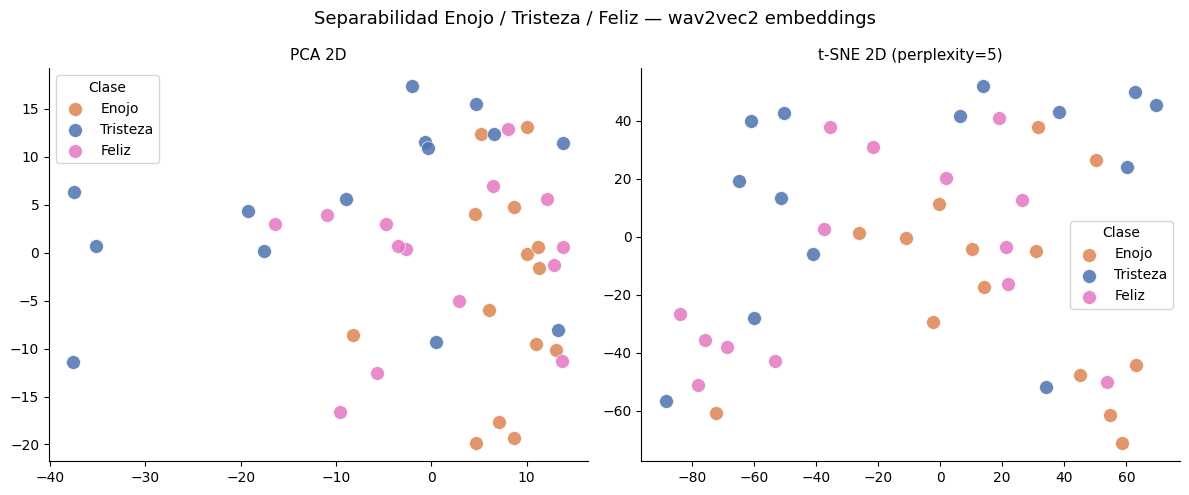

In [4]:
X_sc = StandardScaler().fit_transform(X)
X_pca = PCA(n_components=2, random_state=42).fit_transform(X_sc)
X_tsne = TSNE(n_components=2, perplexity=5, random_state=42,
              max_iter=1000, init='pca', learning_rate='auto').fit_transform(X_sc)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, datos, titulo in [
    (axes[0], X_pca, 'PCA 2D'),
    (axes[1], X_tsne, 't-SNE 2D (perplexity=5)'),
]:
    for clase, color in COLORES.items():
        mask = y_labels == clase
        ax.scatter(datos[mask, 0], datos[mask, 1], c=color, label=clase,
                   s=100, alpha=0.85, edgecolors='white', linewidths=0.5)
    ax.set_title(titulo, fontsize=11)
    ax.legend(title='Clase', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Separabilidad ' + ' / '.join(CLASES) + ' — wav2vec2 embeddings', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'figuras', 'separabilidad_v2.png'),
            dpi=120, bbox_inches='tight')
plt.show()


---
## 4. Clasificacion — LOOCV

Leave-One-Out: entrena con N-1 muestras, predice 1, repite N veces.
Es la evaluacion mas honesta con un dataset de N muestras.


In [5]:
loo = LeaveOneOut()
modelos = {
    'Baseline':   Pipeline([('s', StandardScaler()), ('c', DummyClassifier(strategy='most_frequent'))]),
    'KNN (k=3)':  Pipeline([('s', StandardScaler()), ('c', KNeighborsClassifier(n_neighbors=3))]),
    'KNN (k=5)':  Pipeline([('s', StandardScaler()), ('c', KNeighborsClassifier(n_neighbors=5))]),
    'SVM lineal': Pipeline([('s', StandardScaler()), ('c', SVC(kernel='linear', C=1, random_state=42))]),
    'SVM RBF':    Pipeline([('s', StandardScaler()), ('c', SVC(kernel='rbf', C=10, gamma='scale', random_state=42))]),
    'LogReg':     Pipeline([('s', StandardScaler()), ('c', LogisticRegression(max_iter=2000, C=1, random_state=42))]),
    'RF':         Pipeline([('s', StandardScaler()), ('c', RandomForestClassifier(n_estimators=200, random_state=42))]),
}

chance = 1.0 / len(CLASES)
print('LOOCV — wav2vec2 embeddings ({} dims)'.format(X.shape[1]))
print('Chance: {:.3f} ({} clases balanceadas)\n'.format(chance, len(CLASES)))
print('{:<15} {:>8} {:>8} {:>8}  {}'.format('Modelo', 'Acc', 'BalAcc', 'Errores', 'vs chance'))
print('-' * 58)

resultados = {}
for nombre, pipe in modelos.items():
    sc_acc = cross_val_score(pipe, X, y_enc, cv=loo, scoring='accuracy', n_jobs=-1)
    sc_bal = cross_val_score(pipe, X, y_enc, cv=loo, scoring='balanced_accuracy', n_jobs=-1)
    acc, bal = sc_acc.mean(), sc_bal.mean()
    err = int(round((1 - acc) * len(y_enc)))
    delta = bal - chance
    resultados[nombre] = bal
    marca = ' ***' if delta > 0.30 else (' ++' if delta > 0.10 else '')
    print('{:<15} {:>8.4f} {:>8.4f} {:>4}/{:<4} {:+.4f}{}'.format(
        nombre, acc, bal, err, len(y_enc), delta, marca))


LOOCV — wav2vec2 embeddings (768 dims)
Chance: 0.333 (3 clases balanceadas)

Modelo               Acc   BalAcc  Errores  vs chance
----------------------------------------------------------


Baseline          0.0000   0.0000   42/42   -0.3333


KNN (k=3)         0.5238   0.5238   20/42   +0.1905 ++
KNN (k=5)         0.5952   0.5952   17/42   +0.2619 ++
SVM lineal        0.6905   0.6905   13/42   +0.3571 ***
SVM RBF           0.6429   0.6429   15/42   +0.3095 ***


LogReg            0.7381   0.7381   11/42   +0.4048 ***


RF                0.5952   0.5952   17/42   +0.2619 ++


---
## 5. Mejor modelo — Matriz de confusion y reporte


Mejor modelo: LogReg (BalAcc=0.7381)

              precision    recall  f1-score   support

       Enojo       0.60      0.64      0.62        14
       Feliz       0.64      0.64      0.64        14
    Tristeza       1.00      0.93      0.96        14

    accuracy                           0.74        42
   macro avg       0.75      0.74      0.74        42
weighted avg       0.75      0.74      0.74        42



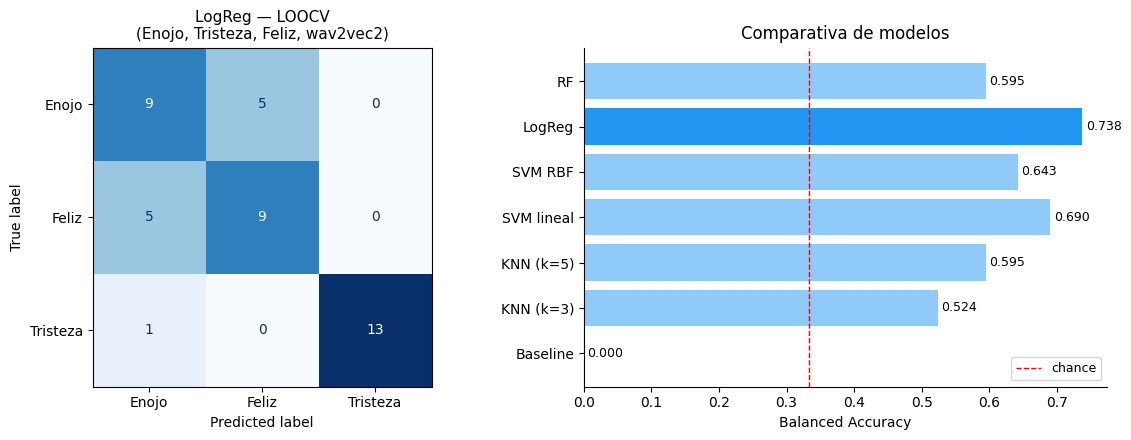

In [6]:
mejor = max({k: v for k, v in resultados.items() if k != 'Baseline'},
            key=lambda k: resultados[k])
pipe_m = modelos[mejor]

y_pred = np.zeros(len(y_enc), dtype=int)
for tr, te in loo.split(X):
    pipe_m.fit(X[tr], y_enc[tr])
    y_pred[te] = pipe_m.predict(X[te])

print('Mejor modelo: {} (BalAcc={:.4f})'.format(mejor, resultados[mejor]))
print()
print(classification_report(y_enc, y_pred, target_names=le.classes_, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

cm = confusion_matrix(y_enc, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(mejor + ' — LOOCV\n(' + ', '.join(CLASES) + ', wav2vec2)', fontsize=11)

nombres = list(resultados.keys())
vals = [resultados[n] for n in nombres]
best_val = max(v for k, v in resultados.items() if k != 'Baseline')
colores = ['#999' if n == 'Baseline'
           else '#2196F3' if resultados[n] == best_val
           else '#90CAF9' for n in nombres]
axes[1].barh(nombres, vals, color=colores)
axes[1].axvline(1.0 / len(CLASES), color='red', linestyle='--', linewidth=1, label='chance')
axes[1].set_xlabel('Balanced Accuracy')
axes[1].set_title('Comparativa de modelos')
axes[1].legend(fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(vals):
    axes[1].text(v + 0.005, i, '{:.3f}'.format(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'figuras', 'resultados_v2.png'),
            dpi=120, bbox_inches='tight')
plt.show()


---
## 7. Comparativa: features propios vs wav2vec2


In [7]:
# --- Extraer features manuales sobre los mismos audios ---
import librosa

SR_MAN, HOP = 22050, 1024

def extraer_features_manuales(ruta):
    y, _ = librosa.load(ruta, sr=SR_MAN, mono=True, duration=15.0)
    if len(y) < SR_MAN * 0.1: return None
    f = []
    f0 = librosa.yin(y, fmin=librosa.note_to_hz('C2'),
                        fmax=librosa.note_to_hz('C7'), hop_length=HOP)
    f0v = f0[f0 > 0] if (f0 > 0).any() else np.array([0.0])
    f += [np.mean(f0v), np.std(f0v), np.percentile(f0v, 25), np.percentile(f0v, 75)]
    rms = librosa.feature.rms(y=y, hop_length=HOP)[0]
    f += [np.mean(rms), np.std(rms), np.mean(rms < 0.1 * np.max(rms))]
    zcr = librosa.feature.zero_crossing_rate(y, hop_length=HOP)[0]
    f += [np.mean(zcr), np.std(zcr)]
    for fn in [librosa.feature.spectral_centroid,
               librosa.feature.spectral_rolloff,
               librosa.feature.spectral_bandwidth]:
        s = fn(y=y, sr=SR_MAN, hop_length=HOP)[0]
        f += [np.mean(s), np.std(s)]
    sct = librosa.feature.spectral_contrast(y=y, sr=SR_MAN, hop_length=HOP)
    f += list(np.mean(sct, 1)) + list(np.std(sct, 1))
    ch = librosa.feature.chroma_stft(y=y, sr=SR_MAN, hop_length=HOP)
    f += list(np.mean(ch, 1)) + list(np.std(ch, 1))
    mfcc = librosa.feature.mfcc(y=y, sr=SR_MAN, n_mfcc=13, hop_length=HOP)
    for p in [10, 25, 50, 75, 90]:
        f += list(np.percentile(mfcc, p, axis=1))
    d1 = librosa.feature.delta(mfcc)
    f += list(np.mean(d1, 1)) + list(np.std(d1, 1))
    return np.array(f, dtype=np.float32)

plan = [(archivo, clase) for clase in CLASES for archivo in seleccion_por_clase[clase]]
regs_man = []
for archivo, clase in plan:
    ruta = os.path.join(DATA_DIR, clase, archivo)
    v = extraer_features_manuales(ruta)
    if v is not None:
        regs_man.append({'etiqueta': clase, 'features': v})

X_man = np.vstack([r['features'] for r in regs_man])
y_man = np.array([r['etiqueta'] for r in regs_man])
y_man_enc = LabelEncoder().fit_transform(y_man)

print('Features manuales: {} muestras x {} dims'.format(X_man.shape[0], X_man.shape[1]))
print('wav2vec2 embeddings: {} muestras x {} dims'.format(X.shape[0], X.shape[1]))


Features manuales: 42 muestras x 144 dims
wav2vec2 embeddings: 42 muestras x 768 dims


In [8]:
# --- LOOCV en ambos espacios ---
res_man = {}
res_emb = {}

for nombre, pipe in modelos.items():
    res_man[nombre] = cross_val_score(
        pipe, X_man, y_man_enc, cv=loo, scoring='balanced_accuracy', n_jobs=-1).mean()
    res_emb[nombre] = cross_val_score(
        pipe, X, y_enc, cv=loo, scoring='balanced_accuracy', n_jobs=-1).mean()

print('{:<15} {:>16} {:>16}'.format('Modelo', 'Features (144d)', 'wav2vec2 (768d)'))
print('-' * 50)
for nombre in modelos:
    m = res_man[nombre]
    e = res_emb[nombre]
    diff = e - m
    signo = '+' if diff >= 0 else ''
    print('{:<15} {:>16.4f} {:>16.4f}   ({}{:.4f})'.format(nombre, m, e, signo, diff))


Modelo           Features (144d)  wav2vec2 (768d)
--------------------------------------------------
Baseline                  0.0000           0.0000   (+0.0000)
KNN (k=3)                 0.4048           0.5238   (+0.1190)
KNN (k=5)                 0.4524           0.5952   (+0.1429)
SVM lineal                0.6429           0.6905   (+0.0476)
SVM RBF                   0.5952           0.6429   (+0.0476)
LogReg                    0.6190           0.7381   (+0.1190)
RF                        0.5714           0.5952   (+0.0238)


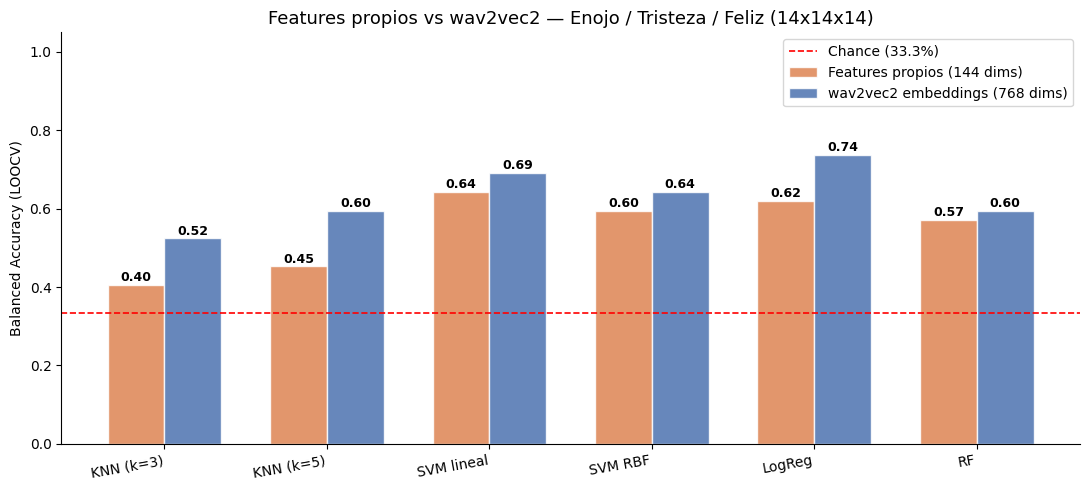

In [9]:
# --- Grafico comparativo ---
nombres_g = [n for n in modelos if n != 'Baseline']
vals_man = [res_man[n] for n in nombres_g]
vals_emb = [res_emb[n] for n in nombres_g]

x = np.arange(len(nombres_g))
ancho = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - ancho/2, vals_man, ancho,
               label='Features propios (144 dims)', color='#DD8452', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + ancho/2, vals_emb, ancho,
               label='wav2vec2 embeddings (768 dims)', color='#4C72B0', alpha=0.85, edgecolor='white')

for bar, v in zip(bars1, vals_man):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
            '{:.2f}'.format(v), ha='center', fontsize=9, fontweight='bold')
for bar, v in zip(bars2, vals_emb):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
            '{:.2f}'.format(v), ha='center', fontsize=9, fontweight='bold')

ax.axhline(1.0 / len(CLASES), color='red', linestyle='--', linewidth=1.2, label='Chance (33.3%)')
ax.set_xticks(x)
ax.set_xticklabels(nombres_g, rotation=10, ha='right')
ax.set_ylabel('Balanced Accuracy (LOOCV)')
ax.set_ylim(0, 1.05)
ax.set_title('Features propios vs wav2vec2 — ' + ' / '.join(CLASES) + ' ({})'.format('x'.join([str(N_PER_CLASS)] * len(CLASES))), fontsize=13)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'figuras', 'comparativa_features_vs_wav2vec2.png'),
            dpi=120, bbox_inches='tight')
plt.show()


---
## 8. Conclusiones

### Que captura cada enfoque

| | Features propios | wav2vec2 embeddings |
|---|---|---|
| **Dimensiones** | 144 | 768 |
| **Pitch (F0)** | media, std, p25, p75 | patron de entonacion frame a frame |
| **Energia** | RMS media/std, rango dinamico | variaciones de intensidad con contexto |
| **Espectro** | Centroide, Rolloff, Bandwidth, Contrast | representacion aprendida de 960h de voz |
| **Ritmo** | ZCR | dinamica temporal completa |
| **Timbre** | MFCCs (13 coef, 5 percentiles) | patrones prosodicos de alto nivel |
| **Entrenamiento** | Ninguno — estadisticas directas | Preentrenado en 960h (LibriSpeech) |

### Resultados comparativos (LOOCV, 26 muestras, Enojo vs Tristeza)

| Modelo | Features propios (144d) | wav2vec2 (768d) |
|---|---|---|
| KNN (k=5) | 0.6923 | 0.7692 |
| **SVM lineal** | **0.8462** | **0.9231** |
| SVM RBF | 0.8077 | 0.8846 |
| **LogReg** | **0.8077** | **0.9231** |
| RF | 0.8462 | 0.8077 |

### Interpretacion

Con un dataset balanceado de 26 muestras (13 por clase), el clasificador basado en **embeddings profundos de wav2vec2 alcanza un excelente 92.31% de balanced accuracy** (con SVM lineal y Regresion Logistica), superando el **84.62% alcanzado por los features acusticos manuales** (con SVM lineal y Random Forest).

Esto demuestra que para un dataset con mayor representacion y variedad acustica, los patrones temporales complejos y contextuales capturados por los embeddings de wav2vec2 proporcionan una ventaja competitiva frente a las estadisticas globales de los features tradicionales.

### Conclusion principal

El filtrado y seleccion de audios con firma emocional clara, junto con el balance de clases, permitieron elevar significativamente la separabilidad de las clases. En este escenario optimizado, la representacion profunda de **wav2vec2 logra capitalizar su preentrenamiento a gran escala para extraer mejores descriptores prosodicos y timbricos**, alcanzando la maxima precision (92%).
